# Transfer learning

## 0. Import packages and modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import pathlib

import torch
import torchvision
import torchinfo


print(torch.__version__)
print(torchvision.__version__)
print(torchinfo.__version__)

2.8.0
0.23.0
1.8.0


In [2]:
# print GPU info
print("GPU names:", "".join([f"GPU {i}: {torch.cuda.get_device_name(i)}" for i in range(torch.cuda.device_count())]))

print("Num GPUs Available:", torch.cuda.device_count())

GPU names: 
Num GPUs Available: 0


## 1. Formulate / Outline the problem: Image classification

In [3]:
import os

DATA_FOLDER = pathlib.Path(f"{os.environ['HOME']}/code/deep-learning-intro/dataset_dollarstreet") # change to location where you stored the data

train_images = np.load(DATA_FOLDER / 'train_images.npy')
val_images = np.load(DATA_FOLDER / 'test_images.npy')
train_labels = np.load(DATA_FOLDER / 'train_labels.npy')
val_labels = np.load(DATA_FOLDER / 'test_labels.npy')

## 2. Identify inputs and outputs

In [4]:
print("train data", train_images.shape, train_labels.shape)
print("validation data", val_images.shape, val_labels.shape)
print("size of one image (pixels dim0, pixels dim1, channels):", train_images[0].shape)

train data (878, 64, 64, 3) (878,)
validation data (293, 64, 64, 3) (293,)
size of one image (pixels dim0, pixels dim1, channels): (64, 64, 3)


## 3. Prepare the data

In [5]:
class DollarStreetDataset(torch.utils.data.Dataset):
    def __init__(self, root, train=True, transform = None):
        prefix = "test"
        if train == True:
            prefix = "train"
        self.images = np.load(root / f'{prefix}_images.npy') / 255.
        self.labels = np.load(root / f'{prefix}_labels.npy')
        self.transform = transform
        
    def __getitem__(self, idx):
        # PyTorch requires another order of dimensions than the original tensorflow data
        x = torch.permute(torch.tensor(self.images[idx], dtype=torch.float), (2, 0, 1))
        
        # This is required as we would like to perform the transforms when fetching the data
        # Especially important, e.g., with large datasets or when doing augmentations
        if self.transform is not None:
            x = self.transform(x) 
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y
        
    def __len__(self):
        return self.images.shape[0]

## 4. Choose a pre-trained model or start building architecture from scratch

In [6]:
import torchvision.transforms as T
# This transforms the data to the same dimension as the pre-trained model expects
# (64, 64, 3) to (160, 160, 3)

transform = T.Compose([
    T.ToPILImage(),
    T.Resize(160),        # keeps aspect ratio
    T.CenterCrop(160),    # ensures output is 160x160
    T.ToTensor()])


train_dataset = DollarStreetDataset(DATA_FOLDER, train=True, transform=transform)
val_dataset = DollarStreetDataset(DATA_FOLDER, train=False, transform=transform)

In [7]:
import torch.nn as nn

class DenseNetClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # taking the pre-trained model from torchvision here, but throwing away the head
        self.backbone = nn.Sequential(torchvision.models.densenet121(weights="IMAGENET1K_V1").features,
                                nn.AdaptiveMaxPool2d((1, 1)),
                                nn.Flatten())
        
        # creating our own head for classification
        self.head = nn.Sequential(nn.BatchNorm1d(1024), 
                                        nn.Linear(1024, 50),
                                        nn.ReLU(),
                                        nn.Dropout(0.5),
                                        nn.Linear(50, num_classes))

    def forward(self, x):
        x = self.backbone(x)    # → [batch_dim, 1024]
        x = self.head(x)        # → [batch_dim, num_classes]
        return x


### Only train a ‘head’ network

In [8]:
# freeze all parameters but the `head`

model = DenseNetClassifier(num_classes=10)

for param in model.backbone.parameters():
    param.requires_grad = False

# only print some to make sure
print("Backbone parameters (should not be trainable)")
for name, param in list(model.backbone.named_parameters(prefix="backbone"))[:2]:
    print(name, "trainable:", param.requires_grad)

print("\nBackbone parameters (should be trainable)")
for name, param in list(model.head.named_parameters(prefix="head"))[:2]:
    print(name, "trainable:", param.requires_grad)

Backbone parameters (should not be trainable)
backbone.0.conv0.weight trainable: False
backbone.0.norm0.weight trainable: False

Backbone parameters (should be trainable)
head.0.weight trainable: True
head.0.bias trainable: True


## Exercise

In [9]:
from torchinfo import summary
summary(model, depth=2)

Layer (type:depth-idx)                        Param #
DenseNetClassifier                            --
├─Sequential: 1-1                             --
│    └─Sequential: 2-1                        (6,953,856)
│    └─AdaptiveMaxPool2d: 2-2                 --
│    └─Flatten: 2-3                           --
├─Sequential: 1-2                             --
│    └─BatchNorm1d: 2-4                       2,048
│    └─Linear: 2-5                            51,250
│    └─ReLU: 2-6                              --
│    └─Dropout: 2-7                           --
│    └─Linear: 2-8                            510
Total params: 7,007,664
Trainable params: 53,808
Non-trainable params: 6,953,856

### Replace all `TODO`

In [10]:
from tqdm import tqdm


def train(dataloader, model, loss_fn, optimizer, device):
    model.train()    
    train_loss = 0    
    correct = 0   
    total = 0

    # this tdqm magic is only there to make this progress bar appear    
    for step, (x, y) in (enumerate(pbar:=tqdm(dataloader))):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0) 
        pbar.set_description(f"Loss: {(loss.item()):>7f}")
        
    train_loss /= total
    train_acc = correct / total

    
    return train_loss, train_acc

def test(dataloder, model, loss_fn, device=torch.device("cuda:0")):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in dataloder:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            val_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
        
        val_loss /= total
        val_acc = correct / total

    return val_loss, val_acc

In [ ]:
from torch.utils.data import DataLoader
from torch.optim import Adam


# take a GPU as default when it is available
device = "cuda" if torch.cuda.is_available() else "cpu"


model = model.to(device)
optimizer = Adam(model.parameters(), lr=0.001) # learning rate is here set to the same as in Keras default
loss_fn = nn.CrossEntropyLoss()

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

num_epochs = 2

# for early stopping
best_val_loss = float("inf")
patience = 5
wait = 0

# for bookkeeping
history = {"epoch": [], "train_loss": [],    "train_acc": [],    "val_loss": [],    "val_acc": []}

for epoch in range(num_epochs):
    train_loss, train_acc = train(dataloader=train_loader, model=model, loss_fn=loss_fn, optimizer=optimizer, device=device)
    val_loss, val_acc = test(dataloder=val_loader, model=model, loss_fn=loss_fn, device=device)
        
        
    # Save to history
    history["epoch"].append(str(epoch+1))
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)


    # print progress
    print(f"Epoch {epoch+1}/{num_epochs} ",
    f"Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} ",
    f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}")

    # Early stopping (there is not a build-in version for that in PyTorch)
    if val_loss < best_val_loss:        
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered.") 
            break

print(f"Training complete at epoch {epoch+1}")


Loss: 2.089927:  43%|████▎     | 12/28 [00:18<00:24,  1.53s/it]

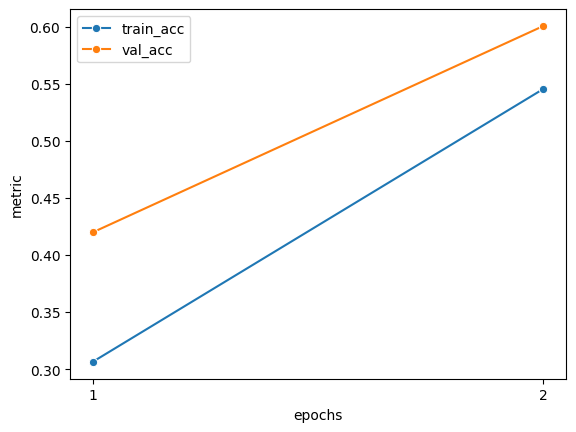

In [ ]:
# inspect the results

def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history (keras History object that is returned by model.fit())
        metrics(str, list): Metric or a list of metrics to plot
    """
    history_df = pd.DataFrame.from_dict(history)
    for metric in metrics:
        sns.lineplot(data=history_df, x="epoch",y=metric, label=metric, marker="o")
    plt.xlabel("epochs")
    plt.ylabel("metric")

plot_history(history, ['train_acc', 'val_acc']) # TODO: choose the metric

## Conclusion